<a href="https://colab.research.google.com/github/anamika24bai10617-sudo/Handwritten-Digit-Recognition/blob/main/Handwritten_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
digits = load_digits()

X = digits.data
y = digits.target

print("Dataset loaded successfully!")
print("Number of images:", len(X))
print("Image size:", digits.images[0].shape)
print("Number of classes:", len(np.unique(y)))

Dataset loaded successfully!
Number of images: 1797
Image size: (8, 8)
Number of classes: 10


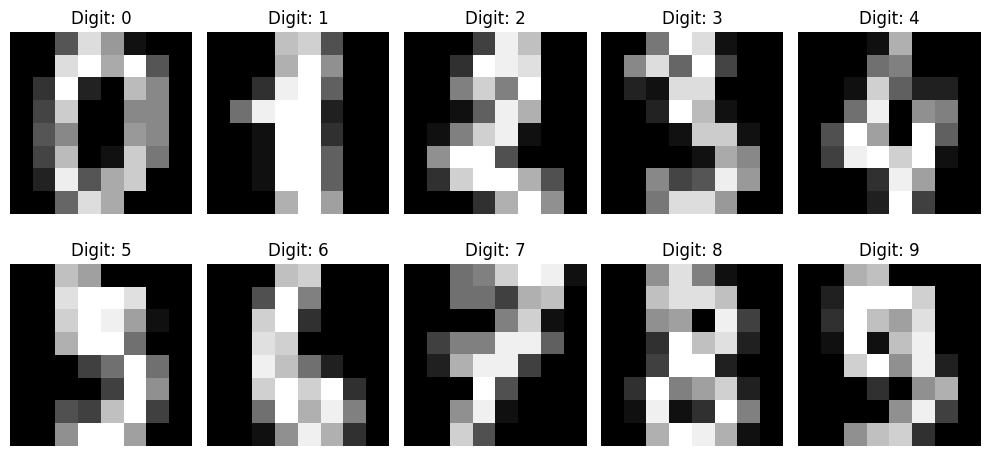

In [3]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(digits.images[i], cmap="gray")
    plt.title("Digit: " + str(y[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training images:", len(X_train))
print("Testing images:", len(X_test))

Training images: 1437
Testing images: 360


In [5]:
model = KNeighborsClassifier(n_neighbors=3)

print("KNN model created!")

KNN model created!


In [6]:
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [8]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")

Model Accuracy: 98.61 %


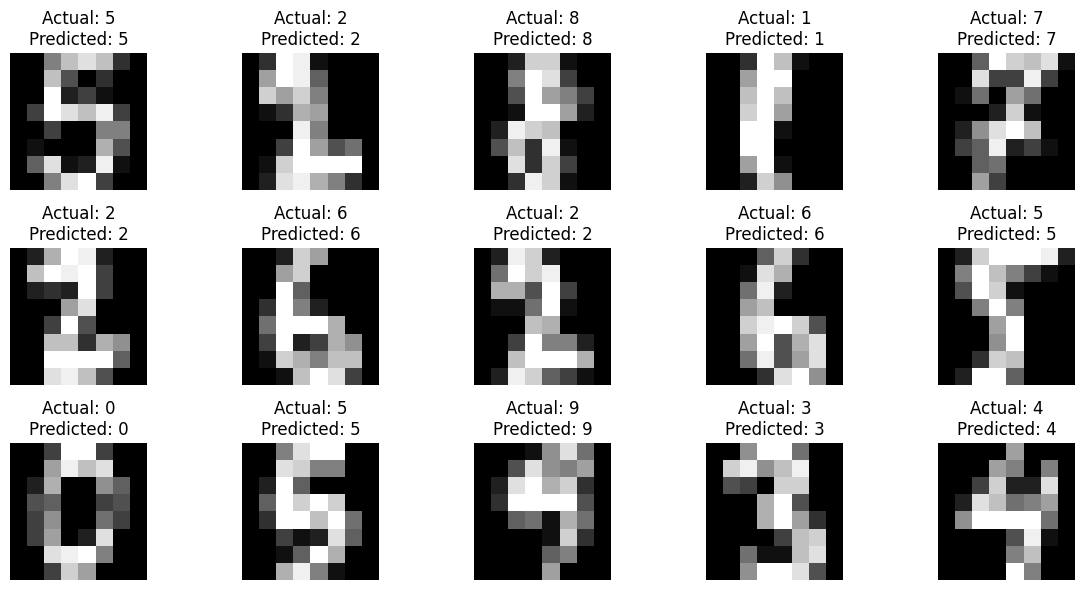

In [9]:
plt.figure(figsize=(12, 6))

for i in range(15):
    plt.subplot(3, 5, i + 1)

    plt.imshow(X_test[i].reshape(8, 8), cmap="gray")

    plt.title(
        "Actual: " + str(y_test[i]) +
        "\nPredicted: " + str(y_pred[i])
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

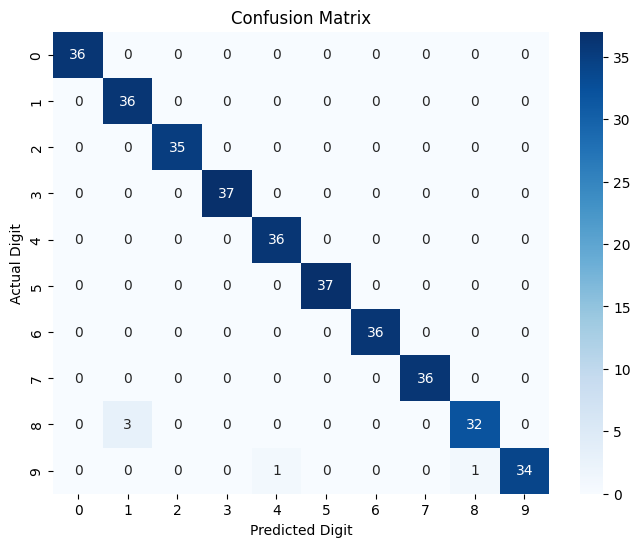

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("Confusion Matrix")

plt.show()

In [11]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.92      1.00      0.96        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       1.00      1.00      1.00        36
           8       0.97      0.91      0.94        35
           9       1.00      0.94      0.97        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360



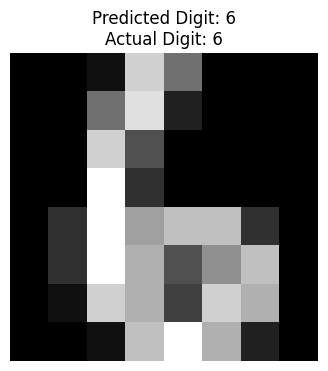

In [13]:
index = 20

image = X_test[index].reshape(8, 8)

prediction = model.predict(
    X_test[index].reshape(1, -1)
)[0]

plt.figure(figsize=(4, 4))
plt.imshow(image, cmap="gray")
plt.title(
    "Predicted Digit: " + str(prediction) +
    "\nActual Digit: " + str(y_test[index])
)
plt.axis("off")
plt.show()

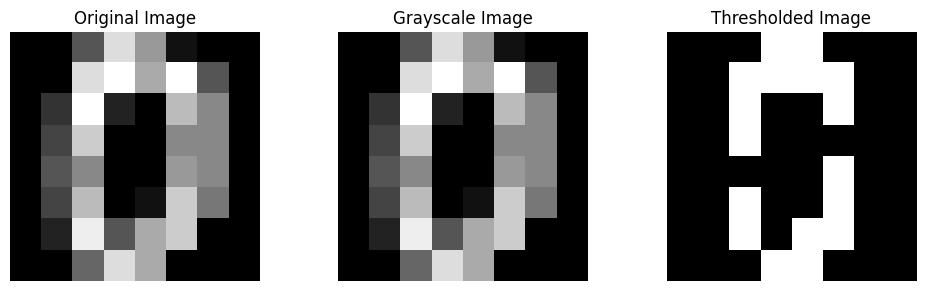

In [14]:
sample_image = digits.images[0]

plt.figure(figsize=(10, 3))

plt.subplot(1, 3, 1)
plt.imshow(sample_image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(sample_image, cmap="gray")
plt.title("Grayscale Image")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(sample_image > 8, cmap="gray")
plt.title("Thresholded Image")
plt.axis("off")

plt.tight_layout()
plt.show()